In [1]:
import os
import numpy as np

import jax
import jax.numpy as jnp
from jax import jacfwd, vmap
from functools import partial
from typing import NamedTuple, Sequence, Callable

import flax.linen as nn
import optax
from soap_jax import soap

import time
import scipy.io
import matplotlib.pyplot as plt

from flax import serialization

from Utilities_talpinn_burgers2d01 import *

In [ ]:
# 1. Data
data_path = "Burgers_2D.mat"
data = scipy.io.loadmat(data_path)

# U 已经按照 (Nt, Ny, Nx) 保存
U_data = jnp.asarray(data["U"])
Nt = jnp.asarray(data["Nt"])
Ny = jnp.asarray(data["Ny"])
Nx = jnp.asarray(data["Nx"])

# MATLAB 中是一行向量，reshape(-1) 转成一维
t = jnp.asarray(data["t"]).reshape(-1)
x = jnp.asarray(data["x"]).reshape(-1)
y = jnp.asarray(data["y"]).reshape(-1)

assert t.shape[0] == Nt
assert x.shape[0] == Nx
assert y.shape[0] == Ny

# 构造 (Nt, Ny, Nx) 坐标张量
# broadcast_to 在表达层面不需要先存储三份完整坐标数据
T_data = jnp.broadcast_to(t[:, None, None], (Nt, Ny, Nx))
X_data = jnp.broadcast_to(x[None, None, :], (Nt, Ny, Nx))
Y_data = jnp.broadcast_to(y[None, :, None], (Nt, Ny, Nx))

t0 = float(T_data[0, 0, 0])
tend = float(T_data[-1, 0, 0])

xL = float(X_data[0, 0, 0])
xR = float(X_data[0, 0, -1])

yL = float(Y_data[0, 0, 0])
yR = float(Y_data[0, -1, 0])

trange = (t0, tend)
xrange = (xL, xR)
yrange = (yL, yR)

T_grid = T_data
X_grid = X_data
Y_grid = Y_data

T_test = T_data[-1]
X_test = X_data[-1]
Y_test = Y_data[-1]
test_labels = U_data[-1].reshape(-1)

print(f"Data grid: Nt={Nt}, Ny={Ny}, Nx={Nx}")
print(f"Time domain: {trange}")
print(f"x domain: {xrange}")
print(f"y domain: {yrange}")
print(f"Test snapshot: t={tend:.6g}")

Data grid: Nt=129, Ny=257, Nx=257
Time domain: (0.0, 1.0)
x domain: (0.0, 4.0)
y domain: (0.0, 4.0)
Test snapshot: t=1


In [3]:
# 2. Random keys and models
seed=11
save_path = "talpinn_burgers2d01_01.msgpack"
key = jax.random.PRNGKey(seed)
key_pde_init, key_coor_init, key_train = jax.random.split(key, 3)

pde_net = FNN_fourier(layer_sizes=[40, 40, 1], activation=nn.silu)
pde_params = pde_net.init(key_pde_init, jnp.ones((5,), dtype=T_grid.dtype))

coor_net = FNN_fourier(layer_sizes=[40, 40, 2], activation=nn.silu)
coor_params = coor_net.init(key_coor_init, jnp.ones((3,), dtype=T_grid.dtype))

# 3. Optimizers and losses
pde_optimizer = soap(learning_rate=3.0e-3, b1=0.95, b2=0.95, weight_decay=0.01, precondition_frequency=10, precondition_1d=False)
coor_optimizer = soap(learning_rate=3.0e-3, b1=0.95, b2=0.95, weight_decay=0.01, precondition_frequency=10, precondition_1d=False)

pde_loss_grad_fn = create_pde_loss_grad_fn( pde_net, w_ic=10.0, w_bc=10.0, jac_floor=1.0e-6, normalize_importance=True)
coor_loss_grad_fn = create_coor_loss_grad_fn(
    coor_net,
    lambda_pos=0.1,
    jac_det_min=1.0e-3,
)
eval_fn = create_eval_fn(pde_net)

identity_map_xieta_to_xy, identity_coor_fn = create_identity_maps(xL, xR, yL, yR)

# 4. Shared helpers
def make_minibatch(map_xieta_to_xy, coor_fn):
    return create_pde_minibatch_fn(IC_map=IC_Burgers_2D, map_xieta_to_xy=map_xieta_to_xy, coor_net=coor_fn, t_bounds=trange, x_bounds=xrange, y_bounds=yrange, dtype=T_grid.dtype)

[Stage 1] JIT warm-up finished.
[Stage 1] iter=00000, time=0.00s | MSE=5.84e-01 | RL2=1.78e+00
[Stage 1] iter=00100, time=1.52s, loss=2.15e+00 | MSE=1.89e-01 | RL2=1.01e+00
[Stage 1] iter=00200, time=2.77s, loss=3.25e-01 | MSE=4.84e-02 | RL2=5.13e-01
[Stage 1] iter=00300, time=4.02s, loss=1.96e-01 | MSE=1.73e-02 | RL2=3.06e-01
[Stage 1] iter=00400, time=5.28s, loss=1.23e-01 | MSE=8.83e-03 | RL2=2.19e-01
[Stage 1] iter=00500, time=6.53s, loss=4.48e-02 | MSE=6.88e-03 | RL2=1.93e-01
[Stage 1] iter=00600, time=7.78s, loss=1.34e-02 | MSE=1.78e-03 | RL2=9.83e-02
[Stage 1] iter=00700, time=9.03s, loss=3.49e-03 | MSE=1.16e-03 | RL2=7.96e-02
[Stage 1] iter=00800, time=10.28s, loss=2.19e-03 | MSE=1.07e-03 | RL2=7.63e-02
[Stage 1] iter=00900, time=11.53s, loss=9.47e-04 | MSE=1.05e-03 | RL2=7.54e-02
[Stage 1] iter=01000, time=12.78s, loss=7.79e-04 | MSE=1.05e-03 | RL2=7.54e-02
[Stage 1] iter=01100, time=14.03s, loss=5.75e-04 | MSE=1.04e-03 | RL2=7.51e-02
[Stage 1] iter=01200, time=15.28s, loss=4.3

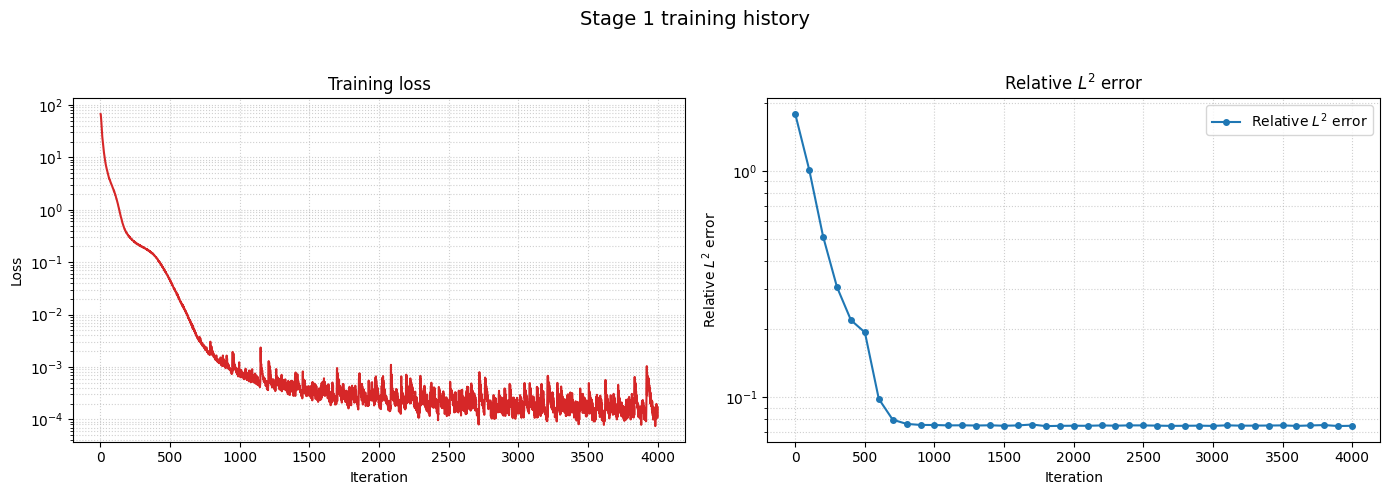

Plotting test grid: nt=1, ny=257, nx=257
Evaluation errors (excluding x+y=2 and x+y=6):
  Full space-time: MSE=1.029290e-03, RL2=7.480954e-02
  Final time     : MSE=1.029290e-03, RL2=7.480954e-02
  Excluded points: full=258, final=258


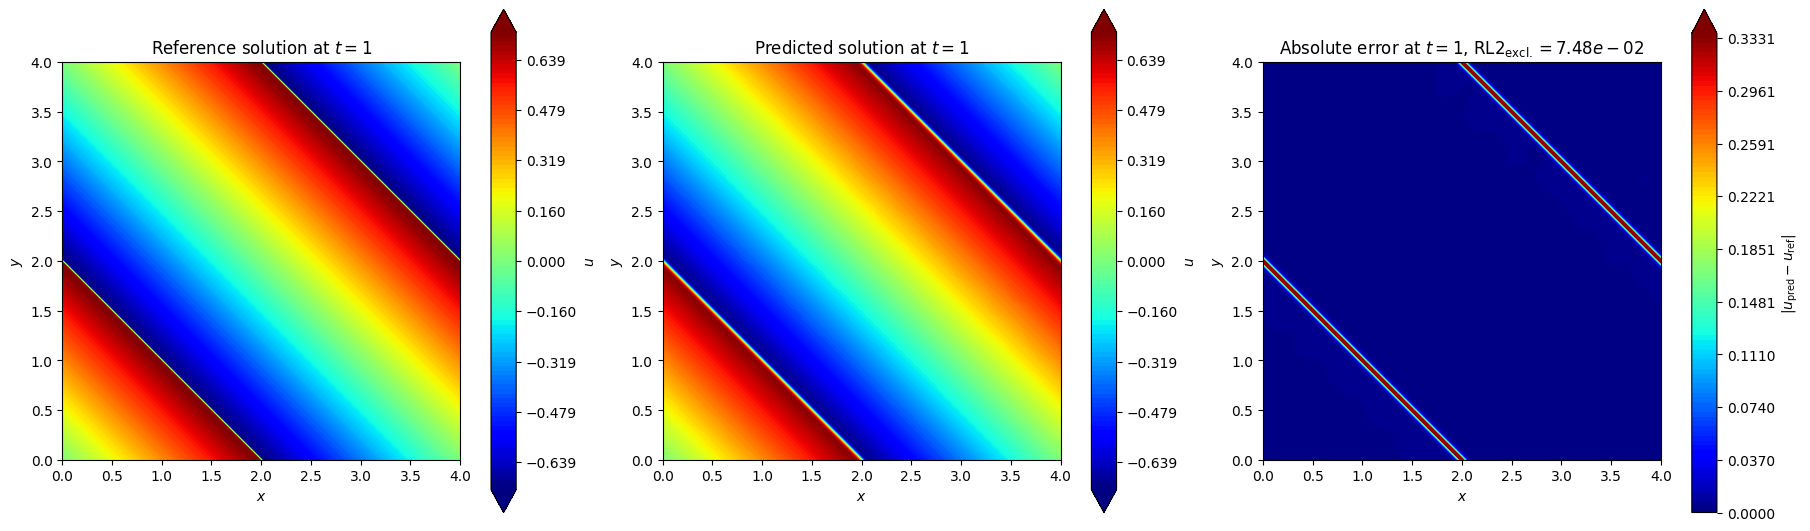

(np.float32(0.0010292903), np.float32(0.074809544))

In [4]:
#stage1
test_inputs_stage1 = create_test_inputs(T_test, X_test, Y_test, identity_coor_fn)
minibatch_stage1 = make_minibatch(identity_map_xieta_to_xy, identity_coor_fn)

pde_params, key_train, history_stage1 = train_pde_stage(stage_name="Stage 1", 
    pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage1,
    eval_fn=eval_fn, test_inputs=test_inputs_stage1, test_labels=test_labels,
    key=key_train, nu=1.0e-2, max_iters=4000, pts_pde=50000, pts_ics=5000, pts_bcs=5000, max_runtime=10000.0, eval_every=100)
pde_params_stage1 = pde_params

plot_training_history(history_stage1, metric="rl2", title=f"Stage 1 training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=T_test, x_test=X_test, y_test=Y_test, labels_test=test_labels, coor_fn=identity_coor_fn)

[Adaptive Mesh] predicted 8520321 points in batches of 131072, time=0.74s
[MMPDE5] steady_iter=4255, steady_residual=9.537e-07, max_time_iter=1305, max_time_residual=9.835e-07, unconverged_steps=0, min_jacobian=1.009e+00
[Adaptive Mesh] method=mmpde5, tau_mesh=2.000e-02, time=22.21s


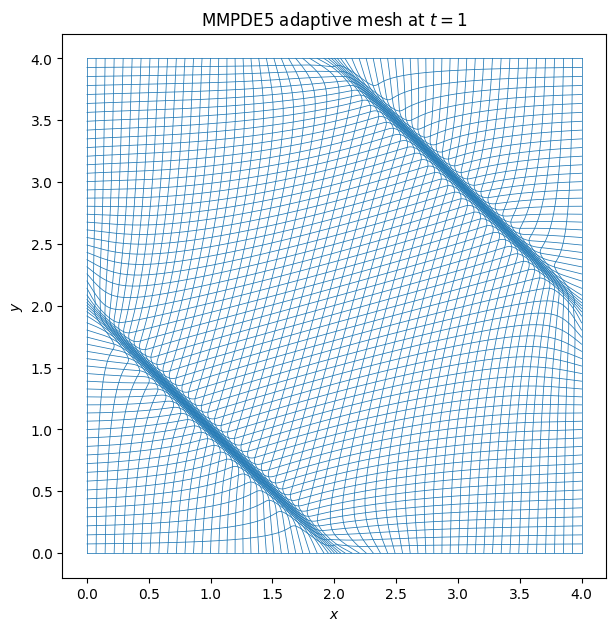

[Coordinate] JIT warm-up finished.
[Coordinate] iter=00100, time=0.26s, batch loss=1.36e-01, full mse=8.61e-02, mse(xi,eta)=(9.12e-02, 8.10e-02)
[Coordinate] iter=00200, time=0.51s, batch loss=5.12e-02, full mse=4.71e-02, mse(xi,eta)=(5.17e-02, 4.25e-02)
[Coordinate] iter=00300, time=0.76s, batch loss=4.46e-03, full mse=3.86e-03, mse(xi,eta)=(5.44e-03, 2.29e-03)
[Coordinate] iter=00400, time=1.00s, batch loss=5.47e-04, full mse=5.20e-04, mse(xi,eta)=(5.08e-04, 5.32e-04)
[Coordinate] iter=00500, time=1.24s, batch loss=1.42e-04, full mse=1.40e-04, mse(xi,eta)=(1.38e-04, 1.42e-04)
[Coordinate] iter=00600, time=1.49s, batch loss=4.29e-05, full mse=4.17e-05, mse(xi,eta)=(4.13e-05, 4.22e-05)
[Coordinate] iter=00700, time=1.73s, batch loss=1.95e-05, full mse=2.10e-05, mse(xi,eta)=(1.85e-05, 2.36e-05)
[Coordinate] iter=00800, time=1.97s, batch loss=1.03e-05, full mse=1.17e-05, mse(xi,eta)=(1.30e-05, 1.05e-05)
[Coordinate] iter=00900, time=2.21s, batch loss=8.01e-06, full mse=7.17e-06, mse(xi,e

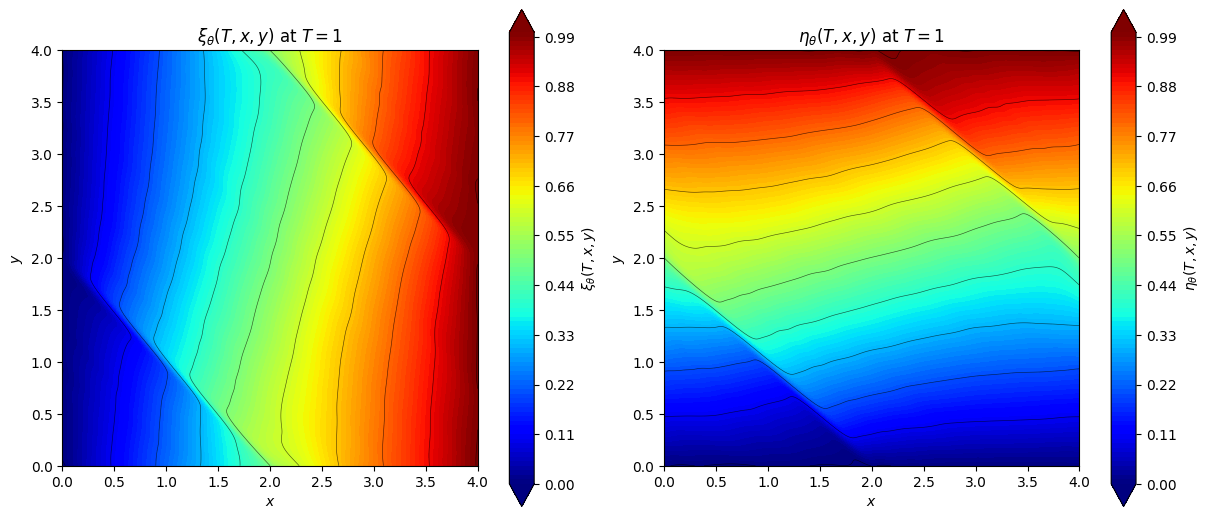

(<Figure size 1200x520 with 4 Axes>,
 array([<Axes: title={'center': '$\\xi_\\theta(T,x,y)$ at $T=1$'}, xlabel='$x$', ylabel='$y$'>,
        <Axes: title={'center': '$\\eta_\\theta(T,x,y)$ at $T=1$'}, xlabel='$x$', ylabel='$y$'>],
       dtype=object))

In [5]:
# Generate first adaptive mesh
xi_grid, eta_grid, Xi_mesh, Eta_mesh, X_adapt, Y_adapt, map_xieta_to_xy, solution_stage1 = generate_adaptive_mesh(
    pde_net,
    pde_params,
    T_grid,
    X_grid,
    Y_grid,
    identity_coor_fn,
    beta=0.5,
    alpha_floor=1.0,
    direction_x=1.0,
    direction_y=1.0,
    smooth_steps=4,
    tau_mesh=2.0e-2,
    steady_tol=1.0e-6,
    steady_max_iter=10000,
    time_tol=1.0e-6,
    time_max_iter=2000,
    relaxation=1.4,
    jacobian_floor=1.0e-6,
    max_move_fraction=0.5,
)
plot_adaptive_mesh(T_grid, X_adapt, Y_adapt, time_index=-1, stride=4)

# Train first coordinate network
coor_params, key_train = train_coordinate_net( coor_net=coor_net, coor_params=coor_params, coor_optimizer=coor_optimizer, coor_loss_grad_fn=coor_loss_grad_fn,
    T_grid=T_grid, X_grid=X_adapt, Y_grid=Y_adapt, Xi_of_xy=Xi_mesh, Eta_of_xy=Eta_mesh,
    key=key_train, max_iters=10000, batch_size=10000, eval_every=100)
coor_params_stage1 = coor_params

trained_coor_fn = create_coor_fn(coor_net, coor_params)
plot_coordinate_mapping(T_grid, X_grid, Y_grid, trained_coor_fn)

[Stage 2] JIT warm-up finished.
[Stage 2] iter=00000, time=0.00s | MSE=1.77e-02 | RL2=3.10e-01
[Stage 2] iter=00100, time=1.49s, loss=2.29e-01 | MSE=1.65e-02 | RL2=3.00e-01
[Stage 2] iter=00200, time=2.97s, loss=1.51e-01 | MSE=4.13e-03 | RL2=1.50e-01
[Stage 2] iter=00300, time=4.45s, loss=7.33e-02 | MSE=1.20e-03 | RL2=8.08e-02
[Stage 2] iter=00400, time=5.93s, loss=4.44e-02 | MSE=9.79e-04 | RL2=7.29e-02
[Stage 2] iter=00500, time=7.41s, loss=3.29e-02 | MSE=6.70e-04 | RL2=6.03e-02
[Stage 2] iter=00600, time=8.88s, loss=2.68e-02 | MSE=4.57e-04 | RL2=4.98e-02
[Stage 2] iter=00700, time=10.36s, loss=2.43e-02 | MSE=3.17e-04 | RL2=4.15e-02
[Stage 2] iter=00800, time=11.84s, loss=2.08e-02 | MSE=2.64e-04 | RL2=3.79e-02
[Stage 2] iter=00900, time=13.32s, loss=1.88e-02 | MSE=2.18e-04 | RL2=3.44e-02
[Stage 2] iter=01000, time=14.79s, loss=1.69e-02 | MSE=2.10e-04 | RL2=3.38e-02
[Stage 2] iter=01100, time=16.27s, loss=1.49e-02 | MSE=1.82e-04 | RL2=3.15e-02
[Stage 2] iter=01200, time=17.75s, loss=1.

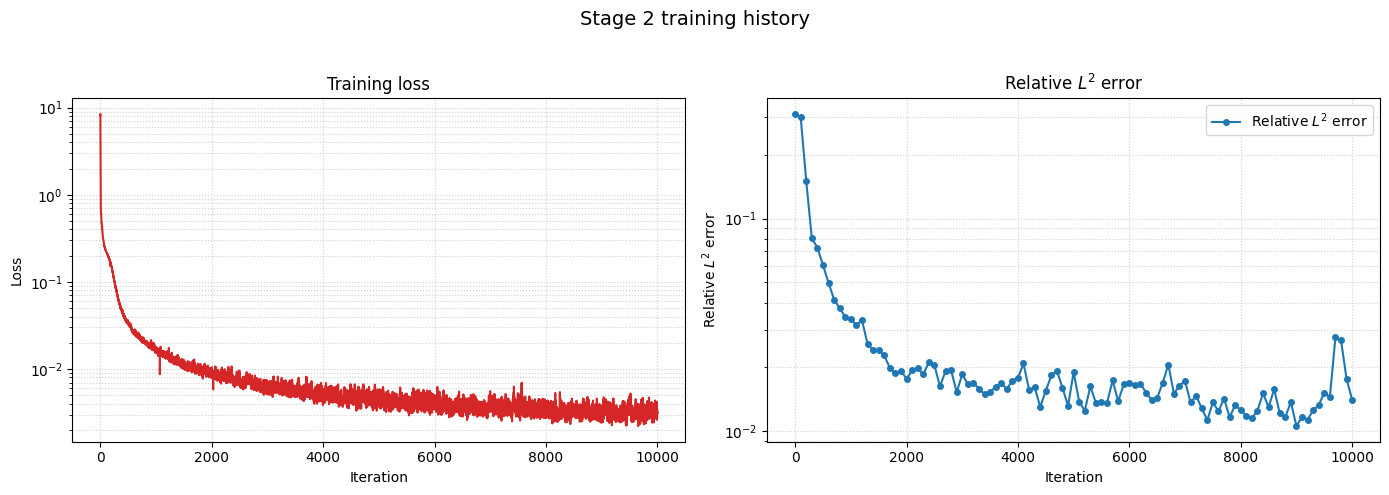

Plotting test grid: nt=1, ny=257, nx=257
Evaluation errors (excluding x+y=2 and x+y=6):
  Full space-time: MSE=3.603913e-05, RL2=1.399830e-02
  Final time     : MSE=3.603913e-05, RL2=1.399830e-02
  Excluded points: full=258, final=258


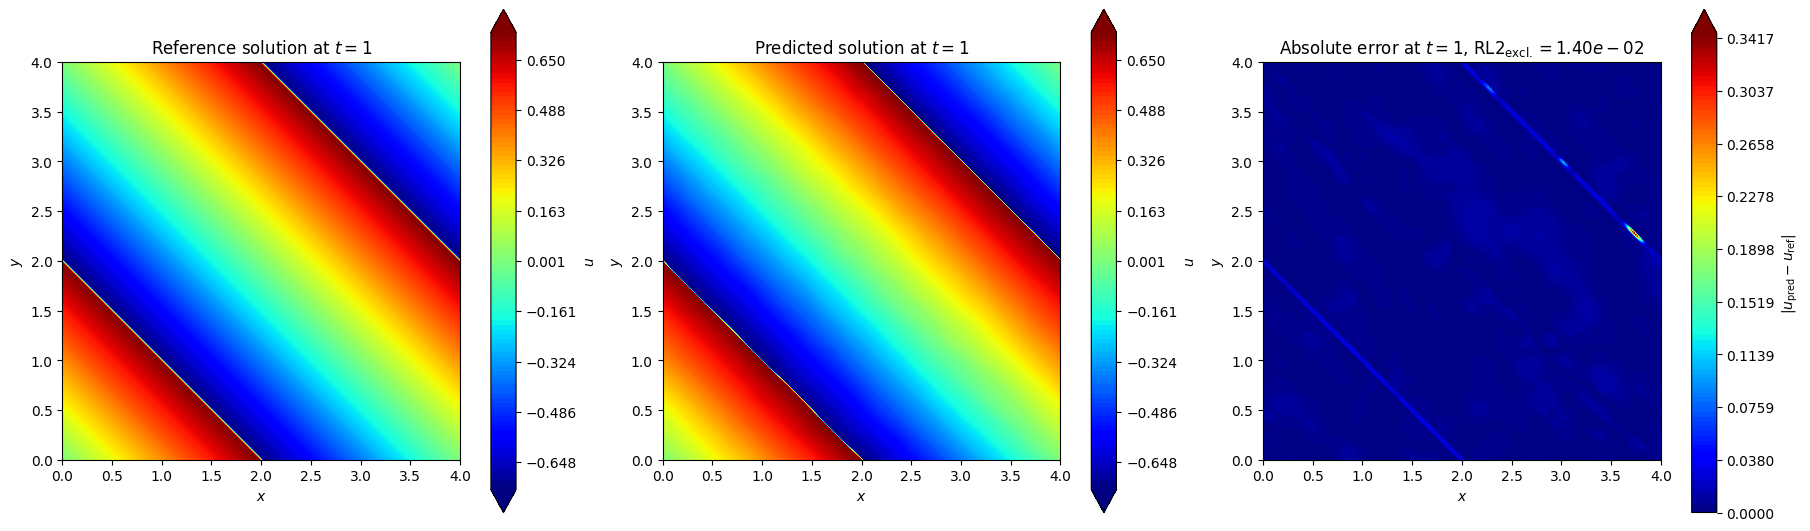

(np.float32(3.6039128e-05), np.float32(0.013998298))

In [6]:
#stage2
test_inputs_stage2 = create_test_inputs(T_test, X_test, Y_test, trained_coor_fn)
minibatch_stage2 = make_minibatch(map_xieta_to_xy, trained_coor_fn)

pde_params, key_train, history_stage2 = train_pde_stage(stage_name="Stage 2", 
    pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage2,
    eval_fn=eval_fn, test_inputs=test_inputs_stage2, test_labels=test_labels,
    key=key_train, nu=1.0e-3, max_iters=10000, pts_pde=50000, pts_ics=5000, pts_bcs=5000, max_runtime=10000.0, eval_every=100)
pde_params_stage2 = pde_params

plot_training_history(history_stage2, metric="rl2", title=f"Stage 2 training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=T_test, x_test=X_test, y_test=Y_test, labels_test=test_labels, coor_fn=trained_coor_fn)

In [7]:
save_training_results(
    pde_params_by_stage={
        "stage1": pde_params_stage1,
        "stage2": pde_params_stage2,
    },
    coor_params_by_stage={
        "stage1": coor_params_stage1,
    },
    pde_histories_by_stage={
        "stage1": history_stage1,
        "stage2": history_stage2,
    },
    checkpoint_path=save_path,
    metadata={
        "data_path": data_path,
        "seed": seed,
        "test_time": tend,
    },
)

Training checkpoint saved to: /home/DG21210022/Amon/tal/burgers2d/talpinn_burgers2d01_01.msgpack
Training histories saved to: /home/DG21210022/Amon/tal/burgers2d/talpinn_burgers2d01_01_history.npz
